# South America

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

uploaded = files.upload()

#low memory parameter
df_filtered = pd.read_csv(io.BytesIO(list(uploaded.values())[0]), low_memory=False)

#print head
print(df_filtered.head())

Saving total_dataset_cleaned.csv to total_dataset_cleaned.csv
       continent                                              title  \
0  South America           M 6.6 - 25 km ESE of Loncopué, Argentina   
1  South America  M 6.5 - 84 km NNW of San Antonio de los Cobres...   
2  South America                  M 6.8 - near the coast of Ecuador   
3  South America             M 6.5 - 107 km SSW of Tarauacá, Brazil   
4  South America                  M 7.2 - 10 km W of Azángaro, Peru   

   magnitude         date_time  cdi  mmi   alert  tsunami    depth  \
0        6.6  17-07-2023 03:05  7.0  5.0   green      0.0  171.371   
1        6.5  22-03-2023 16:00  4.0  4.0   green      0.0  209.976   
2        6.8  18-03-2023 17:12  9.0  7.0  orange      1.0   65.842   
3        6.5     8/6/2022 0:55  3.0  2.0   green      0.0  622.730   
4        7.2  26-05-2022 12:02  7.0  5.0   green      1.0  236.000   

   E_latitude  ...  Coal consumption(Ton) Oil production(ma)  \
0    -38.1911  ...        

In [ ]:
Quakes_Country = (
    df_filtered.groupby("earthquake_country")["magnitude"].count().reset_index(name="Quake_Count")
)

Quakes_Country['Average_Magnitude'] = df_filtered.groupby("earthquake_country")["magnitude"].mean().values
print(Quakes_Country)

  earthquake_country  Quake_Count  Average_Magnitude
0          Argentina            4           6.650000
1            Bolivia            2           6.650000
2             Brazil            3           6.666667
3              Chile           24           6.941667
4           Colombia            2           6.800000
5            Ecuador            5           7.140000
6               Peru           11           7.227273
7          Venezuela            1           7.300000


In [ ]:
df_filtered['date_time'] = pd.to_datetime(df_filtered['date_time'], dayfirst=True, errors='coerce')
Quakes_Yearly = Earthquakes_yearly = df_filtered.groupby(df_filtered['date_time'].dt.year)['magnitude'].count().reset_index(name = "Number of Earthquakes")
print(Earthquakes_yearly)


    date_time  Number of Earthquakes
0      2013.0                      4
1      2014.0                      2
2      2015.0                      8
3      2016.0                      4
4      2017.0                      2
5      2018.0                      3
6      2019.0                      4
7      2020.0                      1
8      2021.0                      1
9      2022.0                      1
10     2023.0                      3


In [ ]:
def Alert(alert):
  if alert == "green":
    return "Green"
  elif alert == "yellow":
    return "Yellow"
  elif alert == "orange":
    return "Orange"

df_filtered['Alert_Count'] = df_filtered['alert'].apply(Alert)
alert_count = df_filtered.groupby('earthquake_country')['Alert_Count'].value_counts().unstack(fill_value=0)
print(alert_count)

Alert_Count         Green  Orange  Yellow
earthquake_country                       
Argentina               4       0       0
Bolivia                 2       0       0
Brazil                  3       0       0
Chile                  18       2       4
Colombia                2       0       0
Ecuador                 2       2       1
Peru                    9       1       1
Venezuela               0       0       1


  Alert Level  Count  Proportion
0       Green     40   76.923077
2      Orange      5    9.615385
1      Yellow      7   13.461538


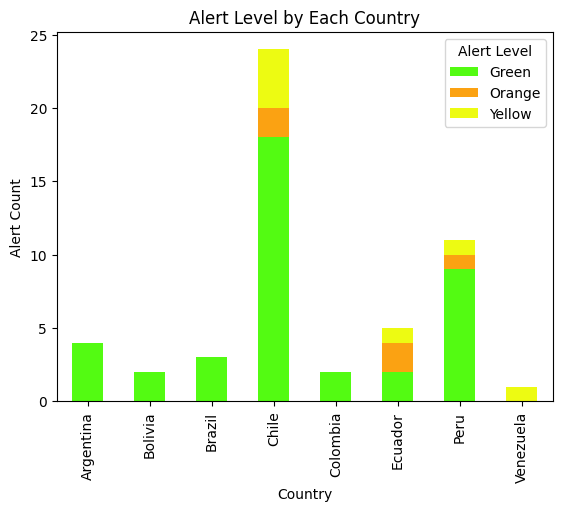

In [ ]:
alerts = df_filtered['Alert_Count'].value_counts().rename_axis('Alert Level').reset_index(name='Count')

total_alerts = alerts['Count'].sum()

alerts['Proportion'] = (alerts['Count'] / total_alerts*100)


alerts = alerts.sort_values('Alert Level')

print(alerts)





color_list: list = [ '#53fb12','#fba212', '#edfb12']


alert_count.plot(kind = 'bar', stacked = True, color = color_list )
plt.title('Alert Level by Each Country')
plt.xlabel('Country')
plt.ylabel('Alert Count')
plt.legend(title = 'Alert Level')
plt.show()



  earthquake_country  Quake_Count  Average_Magnitude  Green  Orange  Yellow
0          Argentina            4           6.650000      4       0       0
1            Bolivia            2           6.650000      2       0       0
2             Brazil            3           6.666667      3       0       0
3              Chile           24           6.941667     18       2       4
4           Colombia            2           6.800000      2       0       0
Shape: (8, 6)
earthquake_country  Argentina   Bolivia    Brazil     Chile  Colombia  \
earthquake_country                                                      
Argentina            1.000000  0.964710  0.988123 -0.618597  0.871583   
Bolivia              0.964710  1.000000  0.992973 -0.759938  0.944179   
Brazil               0.988123  0.992973  1.000000 -0.718137  0.929040   
Chile               -0.618597 -0.759938 -0.718137  1.000000 -0.916931   
Colombia             0.871583  0.944179  0.929040 -0.916931  1.000000   
Ecuador            

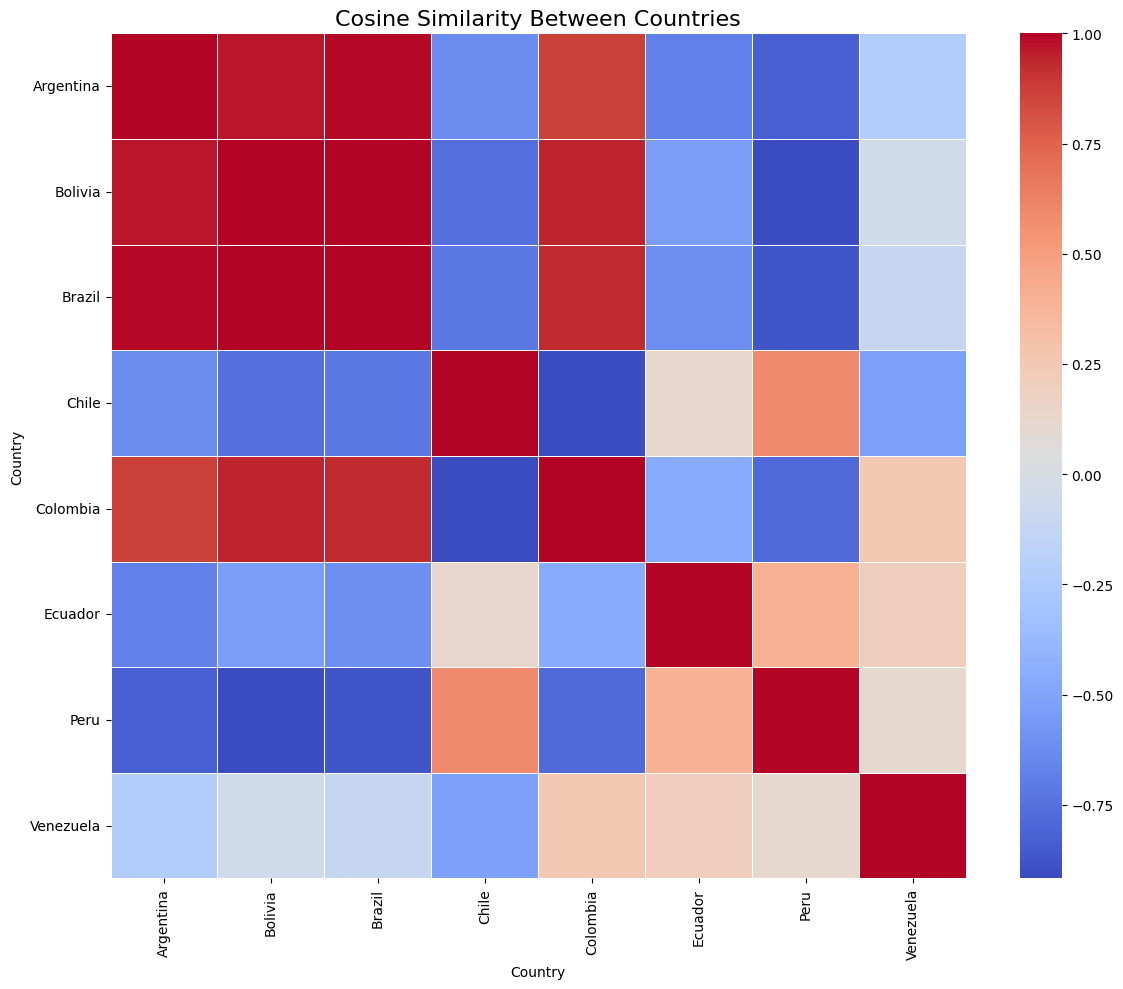

In [ ]:

combined = Quakes_Country.merge(alert_count, on='earthquake_country', how='left')

print(combined.head())
print("Shape:", combined.shape)

features = combined.drop(columns=['earthquake_country'])
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

similarity = cosine_similarity(scaled_features)
cosine_df = pd.DataFrame(similarity, index=combined['earthquake_country'], columns=combined['earthquake_country'])

print(cosine_df)

plt.figure(figsize=(12, 10))
sns.heatmap(cosine_df, cmap='coolwarm', linewidths=0.5, xticklabels=True, yticklabels=True)
plt.title('Cosine Similarity Between Countries', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Country')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

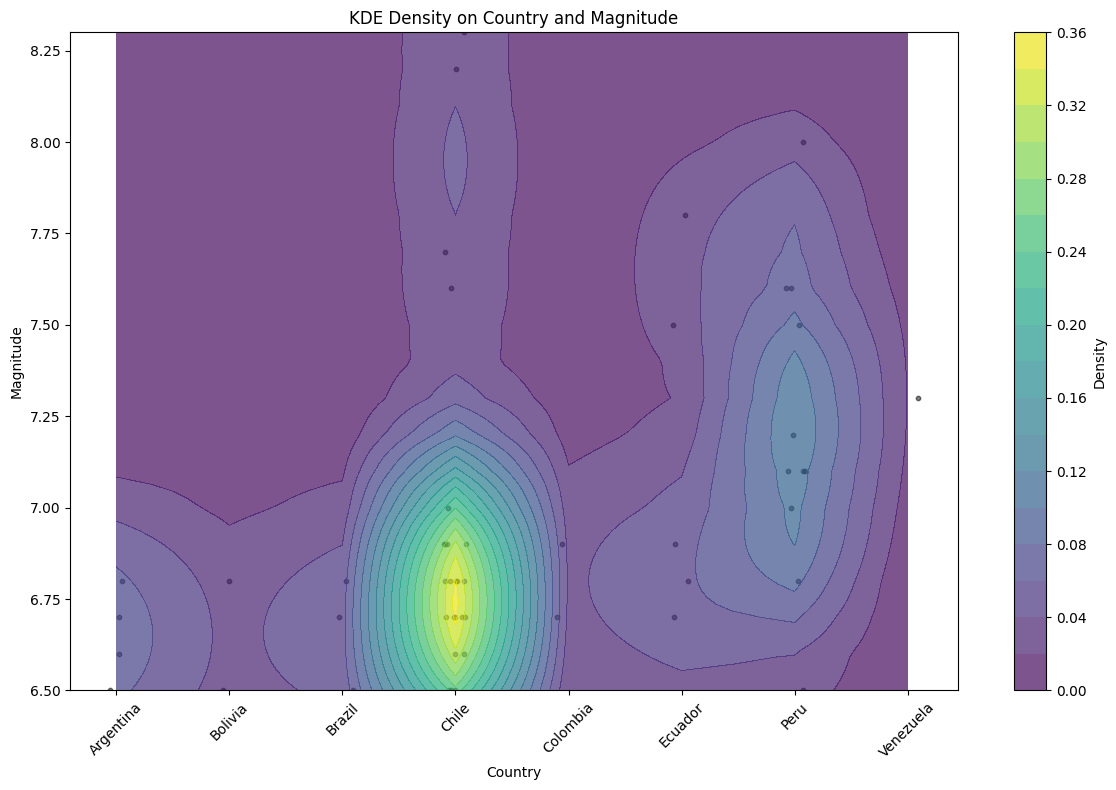

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KernelDensity


le = LabelEncoder()
df_filtered['country_code'] = le.fit_transform(df_filtered['earthquake_country'])


df_filtered = df_filtered.dropna(subset=['country_code', 'magnitude'])




features = df_filtered[['country_code', 'magnitude']].values

kde = KernelDensity(bandwidth=0.5, kernel='cosine')
kde.fit(features)

country_codes = np.arange(df_filtered['country_code'].min(), df_filtered['country_code'].max()+1)
mag_min, mag_max = df_filtered['magnitude'].min(), df_filtered['magnitude'].max()
mag_grid = np.linspace(mag_min, mag_max, 100)

country_grid, mag_grid_mesh = np.meshgrid(country_codes, mag_grid)
grid_points = np.vstack([country_grid.ravel(), mag_grid_mesh.ravel()]).T

log_density = kde.score_samples(grid_points)
density = np.exp(log_density).reshape(mag_grid_mesh.shape)


plt.figure(figsize=(12, 8))
plt.title('KDE Density on Country and Magnitude')

plt.scatter(df_filtered['country_code'] + np.random.uniform(-0.1,0.1,len(df_filtered)),
            df_filtered['magnitude'], s=10, c='k', alpha=0.5, label='Data points')

contour = plt.contourf(country_grid, mag_grid_mesh, density, levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(contour, label='Density')

plt.xticks(ticks=country_codes, labels=le.inverse_transform(country_codes), rotation=45)
plt.xlabel('Country')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io
uploaded = files.upload()

#load TOTAL DATASET SA
#low memory parameter
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]), low_memory=False)

#print head
print(df.head())

Saving total_dataset_cleaned.csv to total_dataset_cleaned (1).csv
       continent                                              title  \
0  South America           M 6.6 - 25 km ESE of Loncopué, Argentina   
1  South America  M 6.5 - 84 km NNW of San Antonio de los Cobres...   
2  South America                  M 6.8 - near the coast of Ecuador   
3  South America             M 6.5 - 107 km SSW of Tarauacá, Brazil   
4  South America                  M 7.2 - 10 km W of Azángaro, Peru   

   magnitude         date_time  cdi  mmi   alert  tsunami    depth  \
0        6.6  17-07-2023 03:05  7.0  5.0   green      0.0  171.371   
1        6.5  22-03-2023 16:00  4.0  4.0   green      0.0  209.976   
2        6.8  18-03-2023 17:12  9.0  7.0  orange      1.0   65.842   
3        6.5     8/6/2022 0:55  3.0  2.0   green      0.0  622.730   
4        7.2  26-05-2022 12:02  7.0  5.0   green      1.0  236.000   

   E_latitude  ...  Coal consumption(Ton) Oil production(ma)  \
0    -38.1911  ...    

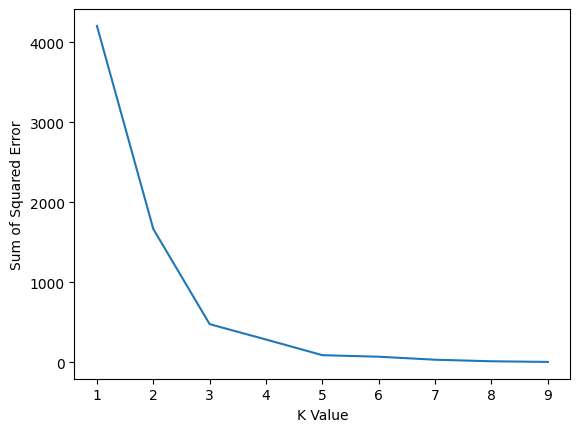

In [ ]:
#Determine value K, preparing for K means cluster model
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

data = df.dropna()


k_range = range(1,10)
sse = []
for k in k_range:
  km = KMeans(n_clusters = k)
  km.fit(data[['Density (KMsq)','CO2EmissionRate (mt)']])
  sse.append(km.inertia_)
sse
plt.xlabel('K Value')
plt.ylabel('Sum of Squared Error')
plt.plot(k_range,sse)

In [ ]:
#Dropping NA values from columns, then predicting kmeans model fit

km = KMeans(n_clusters=3)
y_predicted = km.fit_predict(data[['Density (KMsq)', 'CO2EmissionRate (mt)']])
print(y_predicted)
data['Clusters'] = y_predicted

[0 0 1 1 1 2 0 0 0 0 1 0 1 1]


/tmp/ipython-input-1010897475.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Clusters'] = y_predicted


/tmp/ipython-input-1648952550.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


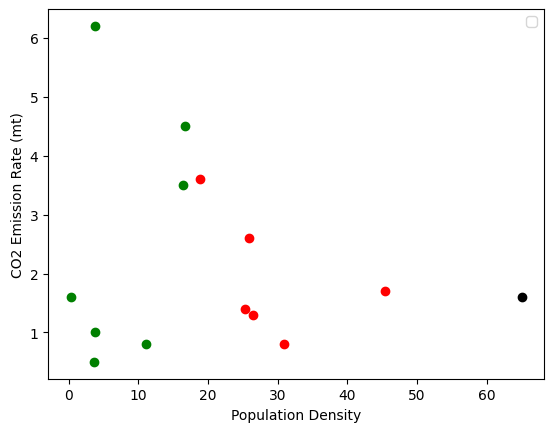

In [ ]:
#Plot K means cluster model

df1 = data[data.Clusters == 0]
df2 = data[data.Clusters == 1]
df3 = data[data.Clusters == 2]

plt.scatter(df1['Density (KMsq)'], df1['CO2EmissionRate (mt)'], color = 'green')
plt.scatter(df2['Density (KMsq)'], df2['CO2EmissionRate (mt)'], color = 'red')
plt.scatter(df3['Density (KMsq)'], df3['CO2EmissionRate (mt)'], color = 'black')
plt.xlabel('Population Density')
plt.ylabel('CO2 Emission Rate (mt)')
plt.legend()
plt.show()

In [ ]:
#Use minmaxscaler if necessary if points dont correlate with center vectors
scaler = MinMaxScaler()
scaler.fit(data[['CO2EmissionRate (mt)']])
data['CO2EmissionRate (mt)'] = scaler.transform(data[['CO2EmissionRate (mt)']])
data.head()
scaler.fit(data[['Density (KMsq)']])
data['Density (KMsq)'] = scaler.transform(data[['Density (KMsq)']])
data.head()

/tmp/ipython-input-1410065139.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['CO2EmissionRate (mt)'] = scaler.transform(data[['CO2EmissionRate (mt)']])
/tmp/ipython-input-1410065139.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Density (KMsq)'] = scaler.transform(data[['Density (KMsq)']])


,continent,title,magnitude,date_time,cdi,mmi,alert,tsunami,depth,E_latitude,...,Oil production(ma),Oil consumption(ma),Gas production per capita(ma),Gas consumption per capita(ma),Coal production per capita(Ton),Coal consumption per capita(Ton),Oil production per capita(ma),Oil consumption per capita(ma),F_Population,Clusters
0,South America,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7.0,5.0,green,0.0,171.371,-38.1911,...,28510000,30850000,284.3,364.4,0.01398,0.04875,1.0220,1.1060,27900000,0
1,South America,M 6.5 - 84 km NNW of San Antonio de los Cobres...,6.5,22-03-2023 16:00,4.0,4.0,green,0.0,209.976,-23.4797,...,28800000,29820000,345.8,361.8,0.01757,0.04344,1.0160,1.0520,28340000,0
2,South America,M 6.8 - near the coast of Ecuador,6.8,18-03-2023 17:12,9.0,7.0,orange,1.0,65.842,-2.8510,...,28510000,28920000,392.4,448.5,0.01789,0.04438,0.9902,1.0040,28790000,1
3,South America,"M 6.5 - 107 km SSW of Tarauacá, Brazil",6.5,8/6/2022 0:55,3.0,2.0,green,0.0,622.730,-9.0618,...,28510000,29470000,430.7,434.5,0.01661,0.04019,0.9744,1.0070,29260000,1
4,South America,"M 7.2 - 10 km W of Azángaro, Peru",7.2,26-05-2022 12:02,7.0,5.0,green,1.0,236.000,-14.8628,...,27760000,28700000,470.5,544.7,0.01712,0.03185,0.9334,0.9652,29740000,1


In [ ]:
#Find cluster centers
km.cluster_centers_

array([[ 7.95102857,  2.58571429],
       [28.82126667,  1.9       ],
       [65.0229    ,  1.6       ]])

/tmp/ipython-input-1157703372.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


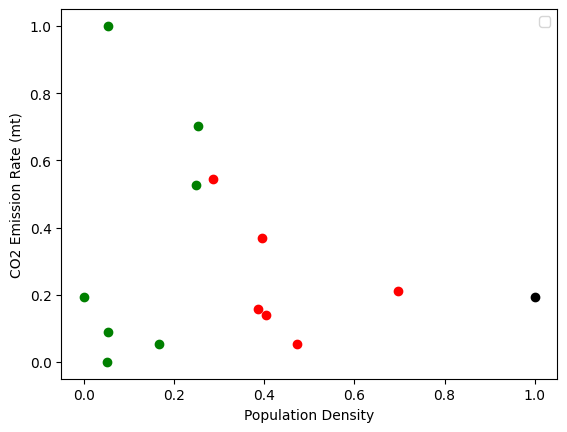

In [ ]:
#With minmaxscaler, plot k means plot, scale was not needed

df1 = data[data.Clusters == 0]
df2 = data[data.Clusters == 1]
df3 = data[data.Clusters == 2]

plt.scatter(df1['Density (KMsq)'], df1['CO2EmissionRate (mt)'], color = 'green')
plt.scatter(df2['Density (KMsq)'], df2['CO2EmissionRate (mt)'], color = 'red')
plt.scatter(df3['Density (KMsq)'], df3['CO2EmissionRate (mt)'], color = 'black')
plt.xlabel('Population Density')
plt.ylabel('CO2 Emission Rate (mt)')
plt.legend()
plt.show()

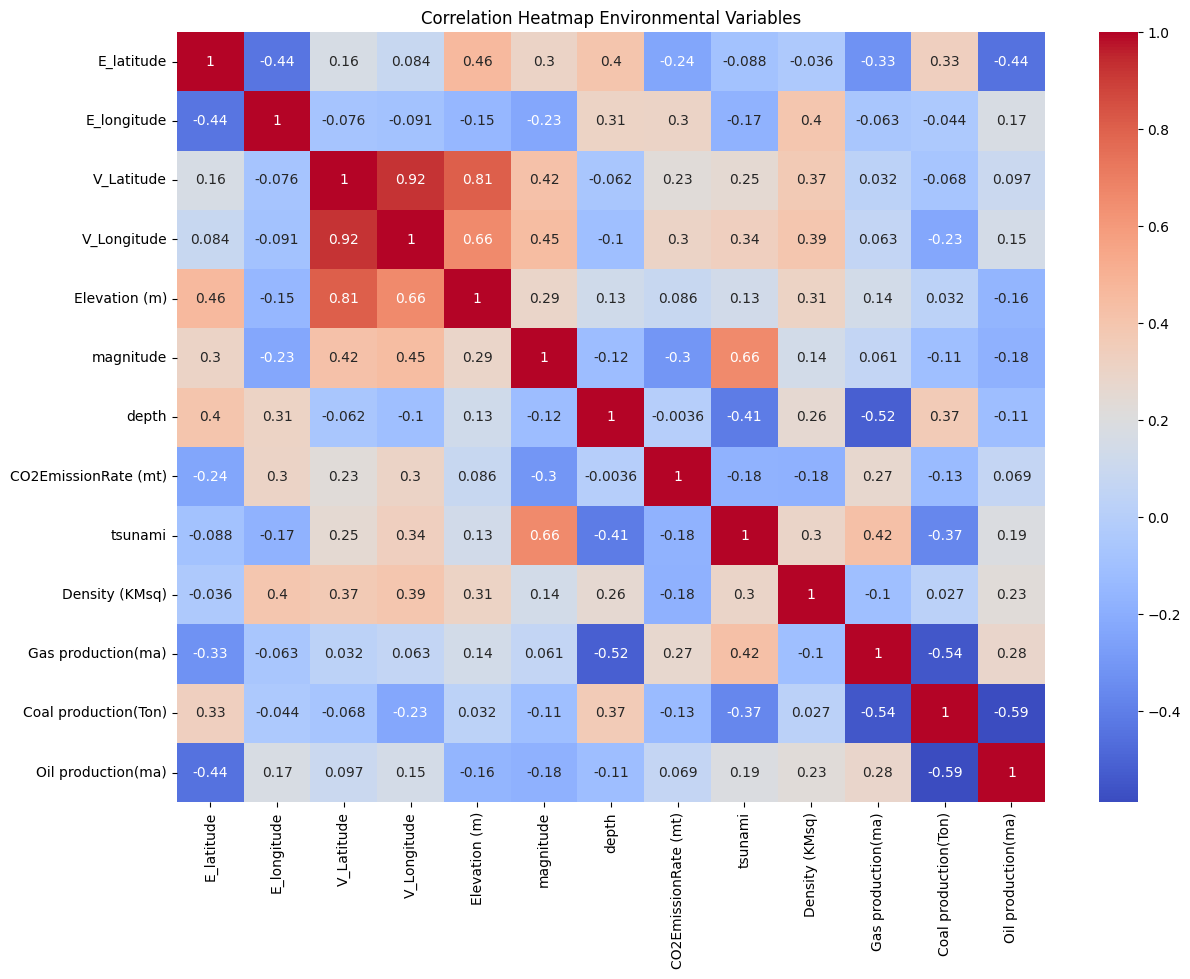

In [ ]:
#Create heatmap to analyze the numerical geographical features of our dataset
#Important features to notice:
  #Tsunami & Magnitude Strong Correlation
  #Earthquake latitude & Depth Medium Correlation
  #Elevation & Volcano Lat & Long indicate cluster of volcanoes naturally forming in high mountainous areas
plt.figure(figsize=(14, 10))
sns.heatmap(data[['E_latitude', 'E_longitude', 'V_Latitude', 'V_Longitude', 'Elevation (m)', 'magnitude', 'depth', 'CO2EmissionRate (mt)','tsunami','Density (KMsq)','Gas production(ma)','Coal production(Ton)','Oil production(ma)']].corr(), annot = True,cmap = "coolwarm")
plt.title("Correlation Heatmap Environmental Variables")
plt.show()

In [ ]:

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler

df_features = data[['E_latitude', 'E_longitude', 'V_Latitude', 'V_Longitude', 'Elevation (m)', 'magnitude', 'depth', 'CO2EmissionRate (mt)',
                    'tsunami','Density (KMsq)','Gas production(ma)','Coal production(Ton)','Oil production(ma)']]
df_features = df_features.dropna()
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_features)
df_scaled = pd.DataFrame(df_scaled, columns = df_features.columns)

df_transposed = df_scaled.transpose()
np.shape(df_transposed)

(13, 14)

In [ ]:
linked = linkage(df_transposed, method = 'ward', metric = 'euclidean')
np.shape(linked)

(12, 4)

In [ ]:
#Create hierarchial clustering model, determining distance from each cluster, and size
df_linked = pd.DataFrame(linked, columns = ['c1', 'c2', 'distance', 'size'])
df_linked[['c1','c2','size']] = df_linked[['c1','c2','size']].astype('int')
df_linked.head(10)

,c1,c2,distance,size
0,2,3,1.458642,2
1,4,13,3.029347,3
2,5,8,3.066406,2
3,0,6,4.093093,2
4,1,9,4.112060,2
5,11,16,4.320259,3
6,10,12,4.484426,2
7,7,19,4.923793,3
8,17,20,5.940210,5
9,14,15,5.996118,5


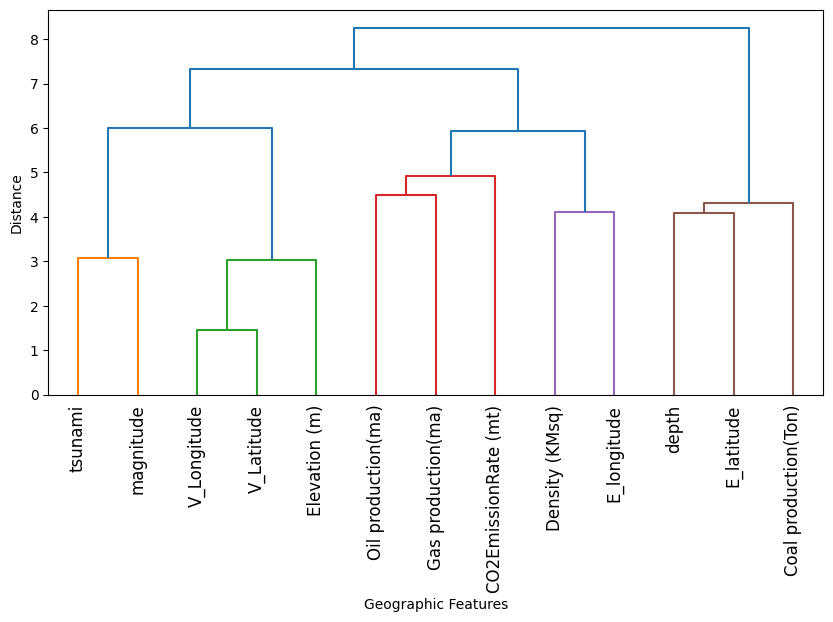

In [ ]:
#visualize dendrogram
plt.figure(figsize=(10,5))
dendrogram(linked, orientation = 'top', labels = df_transposed.index,
           distance_sort = 'descending')

plt.xlabel('Geographic Features')
plt.ylabel('Distance')
plt.xticks(rotation = 90)
plt.show()

In [ ]:
import xgboost as xgb
uploaded = files.upload()
df = pd.read_csv(io.BytesIO(list(uploaded.values())[0]), low_memory=False)
df.columns
#LOAD EARTHQUAKES CLEANED SA


Saving earthquakes_cleaned.csv to earthquakes_cleaned.csv


Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami',
       'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude',
       'longitude', 'location', 'continent', 'country'],
      dtype='object')

In [ ]:
df.columns
df.set_index("date_time")

,title,magnitude,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
date_time,,,,,,,,,,,,,,,,,,
17-07-2023 03:05,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,7,5,green,0,899,us,70,1.634,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
22-03-2023 16:00,M 6.5 - 84 km NNW of San Antonio de los Cobres...,6.5,4,4,green,0,656,us,97,1.622,33.0,mww,209.976,-23.4797,-66.5108,"San Antonio de los Cobres, Argentina",South America,Argentina
18-03-2023 17:12,M 6.8 - near the coast of Ecuador,6.8,9,7,orange,1,1159,us,152,0.709,28.0,mww,65.842,-2.8510,-79.8001,Ecuador,South America,Ecuador
8/6/2022 0:55,"M 6.5 - 107 km SSW of Tarauacá, Brazil",6.5,3,2,green,0,653,us,236,1.999,31.0,mww,622.730,-9.0618,-71.1647,"Tarauacá, Brazil",South America,Brazil
26-05-2022 12:02,"M 7.2 - 10 km W of Azángaro, Peru",7.2,7,5,green,1,876,us,144,2.494,40.0,mww,236.000,-14.8628,-70.3081,"Azángaro, Peru",South America,Peru
10/5/2022 23:06,M 6.8 - 86 km NNW of San Antonio de los Cobres...,6.8,6,5,green,1,762,us,162,1.505,30.0,mww,220.000,-23.6141,-66.7236,"San Antonio de los Cobres, Argentina",South America,Argentina
3/2/2022 15:58,"M 6.5 - 49 km NW of Barranca, Peru",6.5,8,6,green,0,690,us,0,3.026,22.0,mww,110.000,-4.4550,-76.9395,"Barranca, Peru",South America,Peru
28-11-2021 10:52,"M 7.5 - 43 km NNW of Barranca, Peru",7.5,8,8,yellow,1,1094,us,0,4.951,40.0,mww,126.000,-4.4898,-76.8461,"Barranca, Peru",South America,Peru
27-12-2020 21:39,"M 6.7 - 146 km WNW of Corral, Chile",6.7,5,5,green,1,776,us,0,1.319,19.0,mww,10.000,-39.3264,-74.9067,"Corral, Chile",South America,Chile


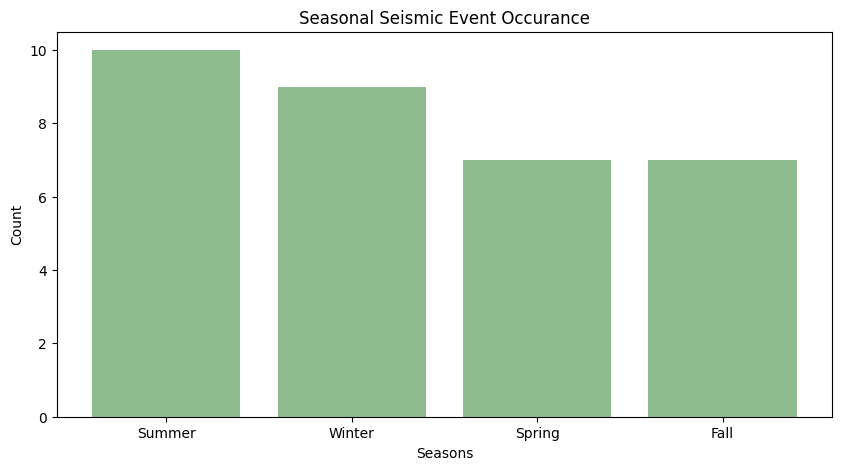

In [ ]:
df.index
df['date_time'] = pd.to_datetime(df['date_time'], dayfirst = True, errors = 'coerce')

def seasons(date):
  year = date.year
  if pd.isna(date):
        return None
  for val in df['date_time']:
    if pd.Timestamp(f"{year}/03/19") <= date < pd.Timestamp(f"{year}/06/20"):
        return "Spring"
    elif pd.Timestamp(f'{year}/06/20') <= date < pd.Timestamp(f'{year}/09/22'):
      return 'Summer'
    elif pd.Timestamp(f'{year}/09/22') <= date < pd.Timestamp(f'{year}/12/21'):
      return 'Fall'
    else:
      return 'Winter'
df['season'] = df['date_time'].apply(seasons)
values = df['season'].value_counts()
plt.figure(figsize= (10,5))
plt.bar(values.index, values, linewidth=0.5, color = 'darkseagreen')
plt.title('Seasonal Seismic Event Occurance')
plt.ylabel('Count')
plt.xlabel('Seasons')
plt.show()


# North America

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

uploaded = files.upload()

#low memory parameter
df_filtered_NA = pd.read_csv(io.BytesIO(list(uploaded.values())[0]), low_memory=False)

#print head
print(df_filtered_NA.head())

Saving NA_DATA.csv to NA_DATA.csv
       continent                                       title  magnitude  \
0  North America  M 7.8 - 206 km SW of Prince Rupert, Canada        7.8   
1  North America                       M 7.2 - Nippes, Haiti        7.2   
2  North America      M 6.8 - 55 km SSW of Aguililla, Mexico        6.8   
3  North America      M 7.6 - 35 km SSW of Aguililla, Mexico        7.6   
4  North America                    M 7.0 - Acapulco, Mexico        7.0   

          date_time  cdi  mmi   alert  tsunami   depth  latitude  ...  \
0  28-10-2012 03:04  8.0  7.0     NaN      0.0  14.000   52.7880  ...   
1  14-08-2021 12:29  9.0  8.0     red      1.0  10.000   18.3521  ...   
2  22-09-2022 06:16  8.0  7.0  yellow      1.0  20.000   18.3300  ...   
3  19-09-2022 18:05  9.0  8.0  yellow      1.0  26.943   18.3667  ...   
4  08-09-2021 01:47  8.0  8.0     red      1.0  20.000   16.9502  ...   

   CO2EmissionRate (mt)                  Name volcanoes_country  \
0        

In [ ]:
Quakes_Country = (
    df_filtered_NA.groupby("earthquake_country")["magnitude"].count().reset_index(name="Quake_Count")
)

Quakes_Country['Average_Magnitude'] =df_filtered_NA.groupby("earthquake_country")["magnitude"].mean().values
print(Quakes_Country)

         earthquake_country  Quake_Count  Average_Magnitude
0                    Canada            1           7.800000
1                     Haiti            1           7.200000
2                    Mexico           24           7.095833
3  United States of America           21           6.995238


In [ ]:
def Alert(alert):
  if alert == "green":
    return "Green"
  elif alert == "yellow":
    return "Yellow"
  elif alert == "orange":
    return "Orange"

df_filtered_NA['Alert_Count'] = df_filtered_NA['alert'].apply(Alert)
alert_count = df_filtered_NA.groupby('earthquake_country')['Alert_Count'].value_counts().unstack(fill_value=0)
print(alert_count)

Alert_Count               Green  Orange  Yellow
earthquake_country                             
Mexico                        0       1       4
United States of America      6       1       2


         earthquake_country  Quake_Count  Average_Magnitude  Green  Orange  \
0                    Canada            1           7.800000    NaN     NaN   
1                     Haiti            1           7.200000    NaN     NaN   
2                    Mexico           24           7.095833    0.0     1.0   
3  United States of America           21           6.995238    6.0     1.0   

   Yellow  
0     NaN  
1     NaN  
2     4.0  
3     2.0  
Shape: (4, 6)
earthquake_country        Mexico  United States of America
earthquake_country                                        
Mexico                       1.0                      -1.0
United States of America    -1.0                       1.0


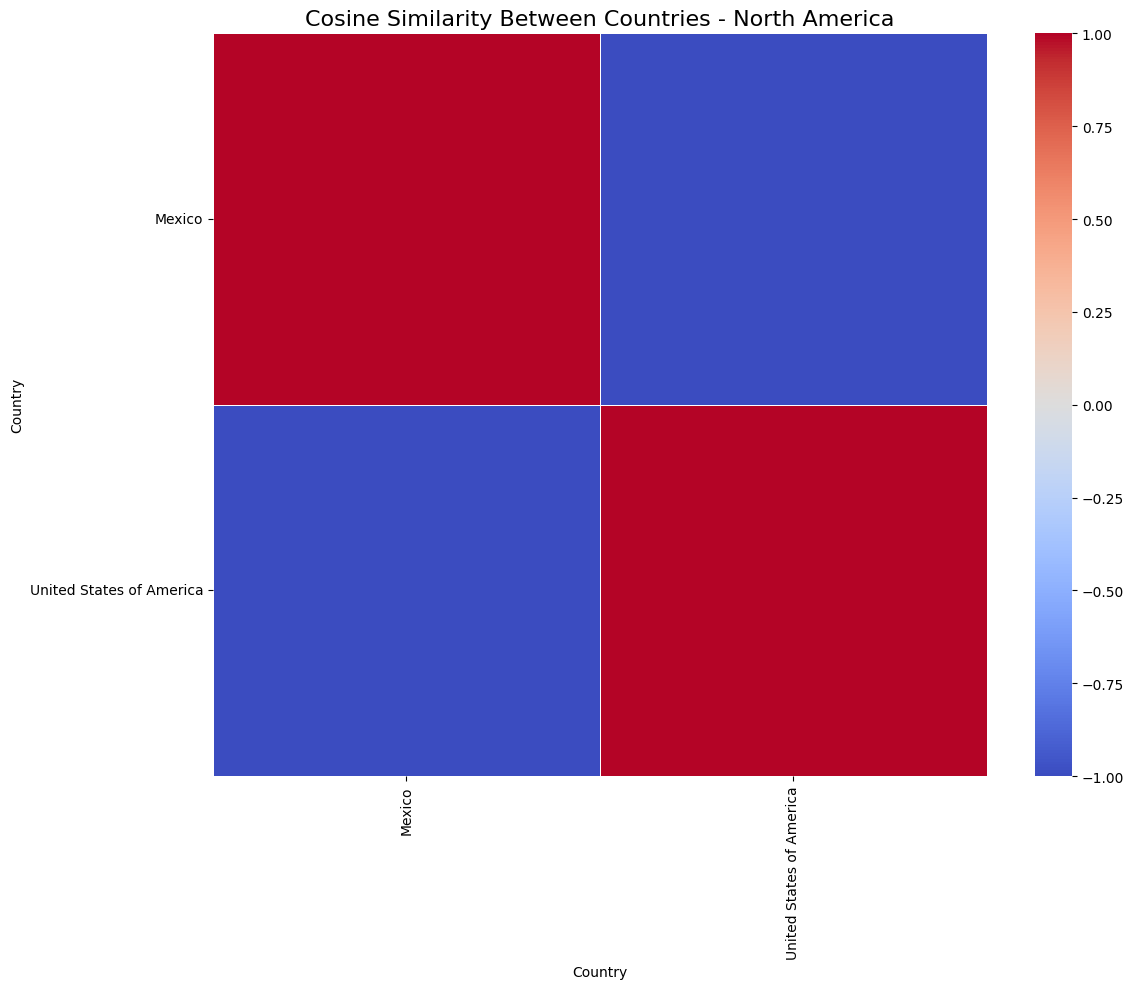

In [ ]:
# Cosign Similarity
combined = Quakes_Country.merge(alert_count, on='earthquake_country', how='left')

print(combined.head())
print("Shape:", combined.shape)

features = combined.drop(columns=['earthquake_country'])

features = features.dropna()

combined = combined.loc[features.index]

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

similarity = cosine_similarity(scaled_features)
cosine_df = pd.DataFrame(similarity,
                         index=combined['earthquake_country'],
                         columns=combined['earthquake_country'])

print(cosine_df)

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cosine_df, cmap='coolwarm', linewidths=0.5,
            xticklabels=True, yticklabels=True)
plt.title('Cosine Similarity Between Countries - North America', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Country')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

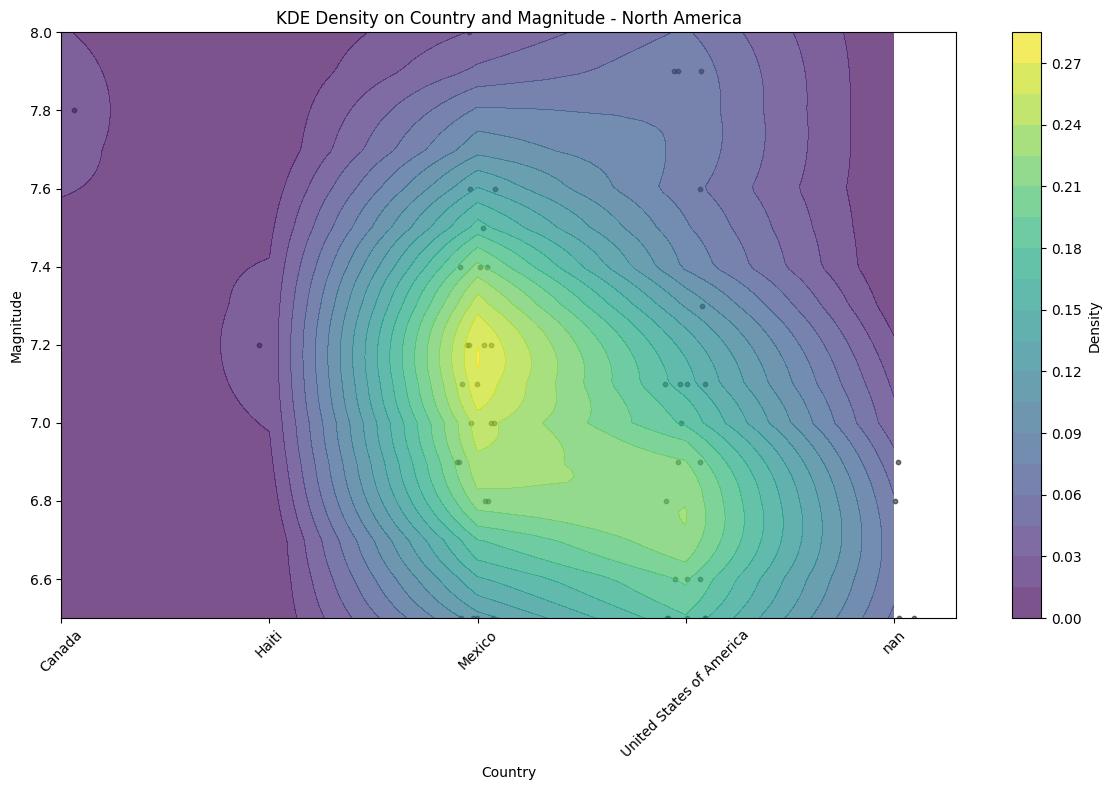

In [ ]:
# KDE Model
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KernelDensity


le = LabelEncoder()
df_filtered_NA['country_code'] = le.fit_transform(df_filtered_NA['earthquake_country'])

df_filtered_NA = df_filtered_NA.dropna(subset=['country_code', 'magnitude'])


features = df_filtered_NA[['country_code', 'magnitude']].values

kde = KernelDensity(bandwidth=0.5, kernel='cosine')
kde.fit(features)

country_codes = np.arange(df_filtered_NA['country_code'].min(), df_filtered_NA['country_code'].max()+1)
mag_min, mag_max = df_filtered_NA['magnitude'].min(), df_filtered_NA['magnitude'].max()
mag_grid = np.linspace(mag_min, mag_max, 100)

country_grid, mag_grid_mesh = np.meshgrid(country_codes, mag_grid)
grid_points = np.vstack([country_grid.ravel(), mag_grid_mesh.ravel()]).T

log_density = kde.score_samples(grid_points)
density = np.exp(log_density).reshape(mag_grid_mesh.shape)


plt.figure(figsize=(12, 8))
plt.title('KDE Density on Country and Magnitude - North America')

plt.scatter(df_filtered_NA['country_code'] + np.random.uniform(-0.1,0.1,len(df_filtered_NA)),
            df_filtered_NA['magnitude'], s=10, c='k', alpha=0.5, label='Data points')

contour = plt.contourf(country_grid, mag_grid_mesh, density, levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(contour, label='Density')

plt.xticks(ticks=country_codes, labels=le.classes_, rotation=45)
plt.xlabel('Country')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()

# Asia

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

uploaded = files.upload()

#low memory parameter
df_filtered_Asia = pd.read_csv(io.BytesIO(list(uploaded.values())[0]), low_memory=False)

#print head
print(df_filtered_Asia.head())

Saving ASIA_DATA.csv to ASIA_DATA (1).csv
  continent                                              title  magnitude  \
0      Asia  M 6.5 - near the east coast of the Kamchatka P...        6.5   
1      Asia               M 7.0 - New Guinea, Papua New Guinea        7.0   
2      Asia             M 6.5 - 40 km SSE of Jurm, Afghanistan        6.5   
3      Asia             M 6.8 - 67 km W of Murghob, Tajikistan        6.8   
4      Asia                M 7.5 - 4 km SSE of Ekinözü, Turkey        7.5   

          date_time  cdi  mmi   alert  tsunami    depth  latitude  ...  \
0  03-04-2023 03:06  7.0  6.0  yellow      1.0  105.631   52.7772  ...   
1  02-04-2023 18:04  7.0  7.0   green      1.0   62.603   -4.2924  ...   
2  21-03-2023 16:47  7.0  5.0   green      0.0  187.589   36.5227  ...   
3  23-02-2023 00:37  9.0  7.0   green      0.0   20.522   38.0726  ...   
4  06-02-2023 10:24  9.0  9.0  orange      0.0   10.000   38.0235  ...   

   CO2EmissionRate (mt)             Name volcanoes

In [ ]:
Quakes_Country = (
    df_filtered_Asia.groupby("earthquake_country")["magnitude"].count().reset_index(name="Quake_Count")
)

Quakes_Country['Average_Magnitude'] = df_filtered_Asia.groupby("earthquake_country")["magnitude"].mean().values
print(Quakes_Country)




def Alert(alert):
  if alert == "green":
    return "Green"
  elif alert == "yellow":
    return "Yellow"
  elif alert == "orange":
    return "Orange"

df_filtered_Asia['Alert_Count'] = df_filtered_Asia['alert'].apply(Alert)
alert_count = df_filtered_Asia.groupby('earthquake_country')['Alert_Count'].value_counts().unstack(fill_value=0)
print(alert_count)

            earthquake_country  Quake_Count  Average_Magnitude
0                  Afghanistan           10           6.730000
1                   Azerbaijan            2           6.650000
2                        India            4           6.975000
3                    Indonesia            3           7.266667
4                         Iran            9           6.866667
5                        Japan           25           6.772000
6                   Kyrgyzstan            1           6.700000
7                     Mongolia            1           6.700000
8                      Myanmar            6           6.800000
9                        Nepal            4           7.100000
10                    Pakistan            5           7.280000
11            Papua New Guinea            1           7.000000
12  People's Republic of China           15           6.973333
13                 Philippines            2           6.850000
14                      Russia           19           6

  earthquake_country  Quake_Count  Average_Magnitude  Green  Orange  Yellow
0        Afghanistan           10           6.730000    2.0     1.0     0.0
1         Azerbaijan            2           6.650000    NaN     NaN     NaN
2              India            4           6.975000    0.0     1.0     0.0
3          Indonesia            3           7.266667    2.0     0.0     0.0
4               Iran            9           6.866667    0.0     0.0     1.0
Shape: (22, 6)
earthquake_country          Afghanistan     India  Indonesia      Iran  \
earthquake_country                                                       
Afghanistan                    1.000000  0.082131  -0.044220 -0.390318   
India                          0.082131  1.000000   0.111062  0.055713   
Indonesia                     -0.044220  0.111062   1.000000 -0.415830   
Iran                          -0.390318  0.055713  -0.415830  1.000000   
Japan                          0.382793 -0.704453  -0.347480 -0.174257   
Mongolia   

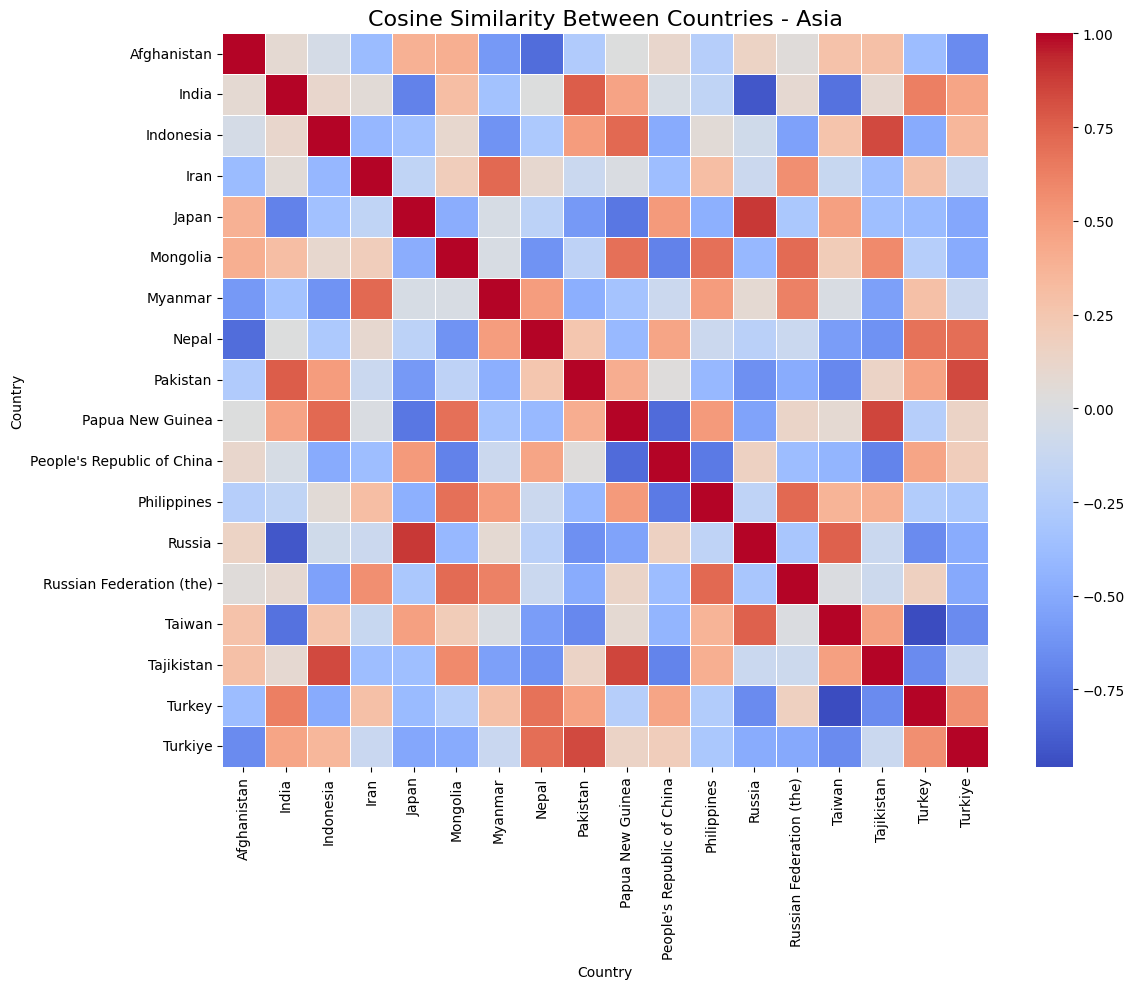

In [ ]:
# Cosign Similarity Model
combined = Quakes_Country.merge(alert_count, on='earthquake_country', how='left')

print(combined.head())
print("Shape:", combined.shape)

# Drop the country column to isolate numeric features
features = combined.drop(columns=['earthquake_country'])

# ✅ Remove any rows that contain NaN values
features = features.dropna()

# ✅ Keep the corresponding countries aligned with the cleaned data
combined = combined.loc[features.index]

# Scale the numeric features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Compute cosine similarity
similarity = cosine_similarity(scaled_features)
cosine_df = pd.DataFrame(similarity,
                         index=combined['earthquake_country'],
                         columns=combined['earthquake_country'])

print(cosine_df)

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cosine_df, cmap='coolwarm', linewidths=0.5,
            xticklabels=True, yticklabels=True)
plt.title('Cosine Similarity Between Countries - Asia', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Country')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

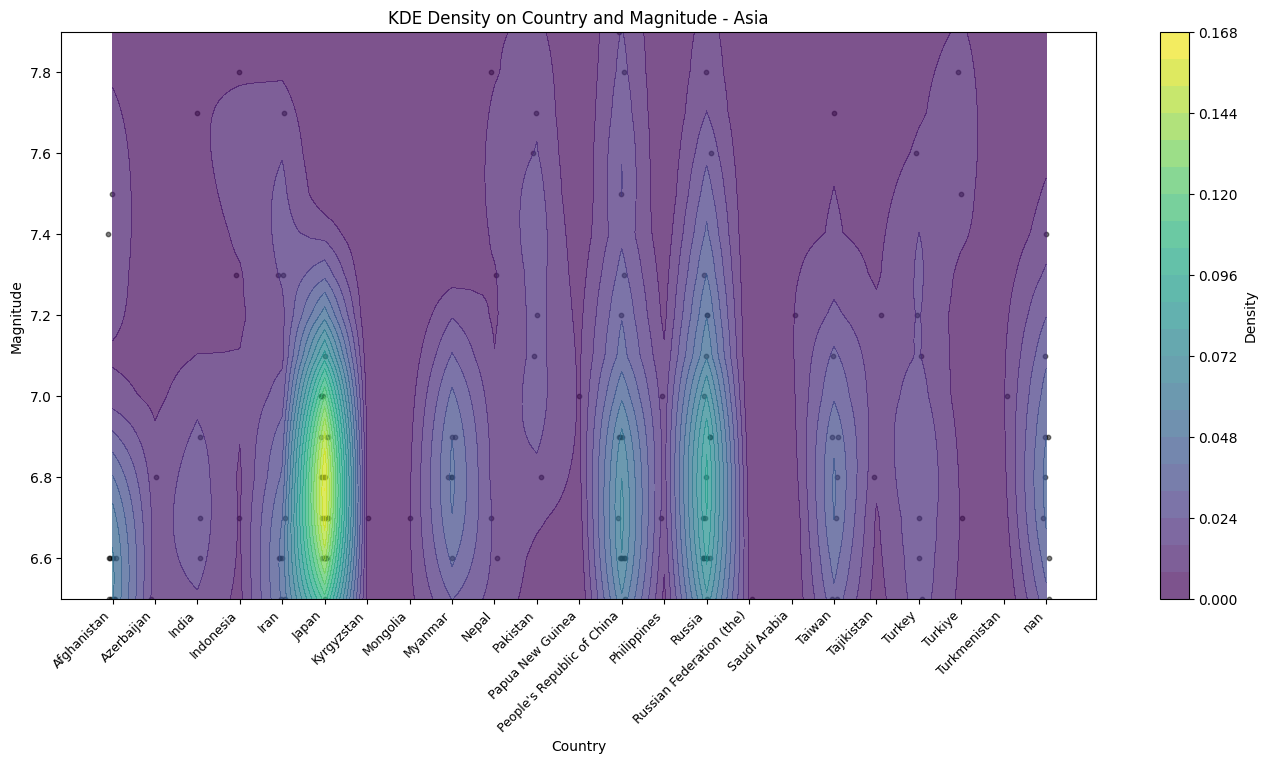

In [ ]:
# KDE Model

from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KernelDensity

le = LabelEncoder()
df_filtered_Asia['country_code'] = le.fit_transform(df_filtered_Asia['earthquake_country'])

df_filtered_Asia = df_filtered_Asia.dropna(subset=['country_code', 'magnitude'])

features = df_filtered_Asia[['country_code', 'magnitude']].values

kde = KernelDensity(bandwidth=0.5, kernel='cosine')
kde.fit(features)

country_codes = np.arange(df_filtered_Asia['country_code'].min(), df_filtered_Asia['country_code'].max()+1)
mag_min, mag_max = df_filtered_Asia['magnitude'].min(), df_filtered_Asia['magnitude'].max()
mag_grid = np.linspace(mag_min, mag_max, 100)

country_grid, mag_grid_mesh = np.meshgrid(country_codes, mag_grid)
grid_points = np.vstack([country_grid.ravel(), mag_grid_mesh.ravel()]).T

log_density = kde.score_samples(grid_points)
density = np.exp(log_density).reshape(mag_grid_mesh.shape)

plt.figure(figsize=(14, 8))
plt.title('KDE Density on Country and Magnitude - Asia')

plt.scatter(df_filtered_Asia['country_code'] + np.random.uniform(-0.1,0.1,len(df_filtered_Asia)),
            df_filtered_Asia['magnitude'], s=10, c='k', alpha=0.5, label='Data points')
contour = plt.contourf(country_grid, mag_grid_mesh, density, levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(contour, label='Density')

plt.xticks(ticks=country_codes, labels=le.classes_, rotation=45, ha='right', fontsize=9)
plt.xlabel('Country')
plt.ylabel('Magnitude')
plt.tight_layout(pad=2.0)
plt.show()

plt.show()




# Oceania

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io

uploaded = files.upload()

#low memory parameter
df_filtered_Oceania = pd.read_csv(io.BytesIO(list(uploaded.values())[0]), low_memory=False)

#print head
print(df_filtered_Oceania.head())

Saving OCEANIA_DATA.csv to OCEANIA_DATA (1).csv
  continent                                         title  magnitude  \
0   Oceania              M 6.5 - 42 km W of Sola, Vanuatu        6.5   
1   Oceania          M 7.0 - New Guinea, Papua New Guinea        7.0   
2   Oceania  M 6.5 - 108 km NW of Kimbe, Papua New Guinea        6.5   
3   Oceania                               M 7.0 - Vanuatu        7.0   
4   Oceania  M 7.0 - 18 km SW of Malango, Solomon Islands        7.0   

          date_time  cdi  mmi  alert  tsunami    depth  latitude  ...  \
0  16-08-2023 12:47  7.0  4.0  green      0.0  192.955  -13.8814  ...   
1  02-04-2023 18:04  7.0  7.0  green      1.0   62.603   -4.2924  ...   
2  01-03-2023 05:36  4.0  2.0  green      1.0  598.925   -4.8138  ...   
3  08-01-2023 12:32  8.0  7.0  green      1.0   29.000  -14.9383  ...   
4  22-11-2022 02:03  8.0  7.0  green      1.0   14.000   -9.7963  ...   

   Longitude    Number            Type  Latitude  Year.1  Country.2  \
0   -170.

In [ ]:
Quakes_Country = (
    df_filtered_Oceania.groupby("earthquake_country")["magnitude"].count().reset_index(name="Quake_Count")
)

Quakes_Country['Average_Magnitude'] = df_filtered_Oceania.groupby("earthquake_country")["magnitude"].mean().values
print(Quakes_Country)




def Alert(alert):
  if alert == "green":
    return "Green"
  elif alert == "yellow":
    return "Yellow"
  elif alert == "orange":
    return "Orange"

df_filtered_Oceania['Alert_Count'] = df_filtered_Oceania['alert'].apply(Alert)
alert_count = df_filtered_Oceania.groupby('earthquake_country')['Alert_Count'].value_counts().unstack(fill_value=0)
print(alert_count)

  earthquake_country  Quake_Count  Average_Magnitude
0               Fiji           10           7.100000
1        New Zealand            9           6.955556
2   Papua New Guinea           81           6.897531
3    Solomon Islands           25           6.876000
4              Tonga            1           6.600000
5            Vanuatu           36           6.861111
Alert_Count         Green  Orange  Yellow
earthquake_country                       
Fiji                    7       0       0
New Zealand             0       1       4
Papua New Guinea       25       0       5
Solomon Islands        11       0       0
Vanuatu                15       0       0


  earthquake_country  Quake_Count  Average_Magnitude  Green  Orange  Yellow
0               Fiji           10           7.100000    7.0     0.0     0.0
1        New Zealand            9           6.955556    0.0     1.0     4.0
2   Papua New Guinea           81           6.897531   25.0     0.0     5.0
3    Solomon Islands           25           6.876000   11.0     0.0     0.0
4              Tonga            1           6.600000    NaN     NaN     NaN
Shape: (6, 6)
earthquake_country      Fiji  New Zealand  Papua New Guinea  Solomon Islands  \
earthquake_country                                                             
Fiji                1.000000     0.013054         -0.623103        -0.053466   
New Zealand         0.013054     1.000000         -0.435762        -0.471884   
Papua New Guinea   -0.623103    -0.435762          1.000000        -0.336667   
Solomon Islands    -0.053466    -0.471884         -0.336667         1.000000   
Vanuatu            -0.342277    -0.702490         

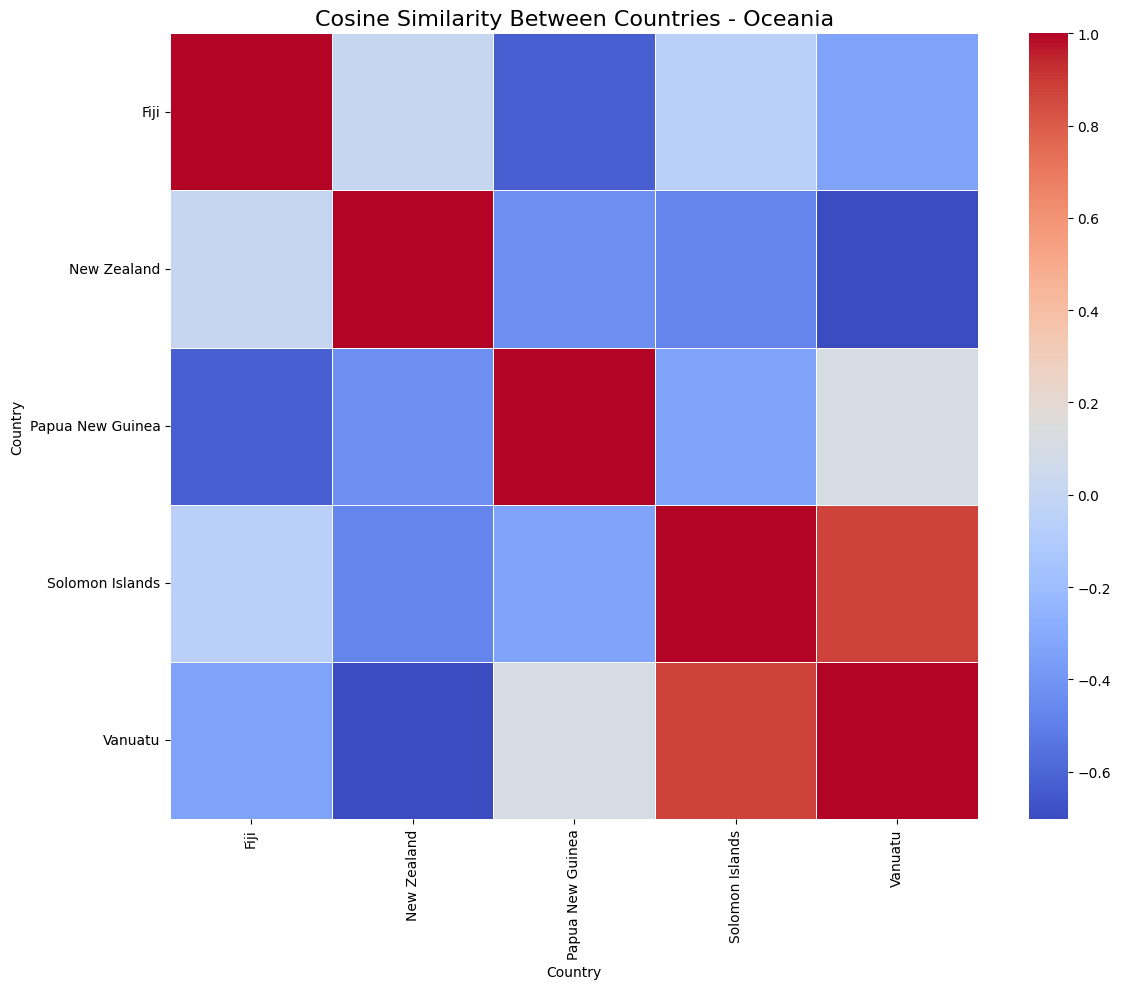

In [ ]:
# Cosign Similarity Model
combined = Quakes_Country.merge(alert_count, on='earthquake_country', how='left')

print(combined.head())
print("Shape:", combined.shape)

# Drop the country column to isolate numeric features
features = combined.drop(columns=['earthquake_country'])

# ✅ Remove any rows that contain NaN values
features = features.dropna()

# ✅ Keep the corresponding countries aligned with the cleaned data
combined = combined.loc[features.index]

# Scale the numeric features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Compute cosine similarity
similarity = cosine_similarity(scaled_features)
cosine_df = pd.DataFrame(similarity,
                         index=combined['earthquake_country'],
                         columns=combined['earthquake_country'])

print(cosine_df)

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cosine_df, cmap='coolwarm', linewidths=0.5,
            xticklabels=True, yticklabels=True)
plt.title('Cosine Similarity Between Countries - Oceania', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Country')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

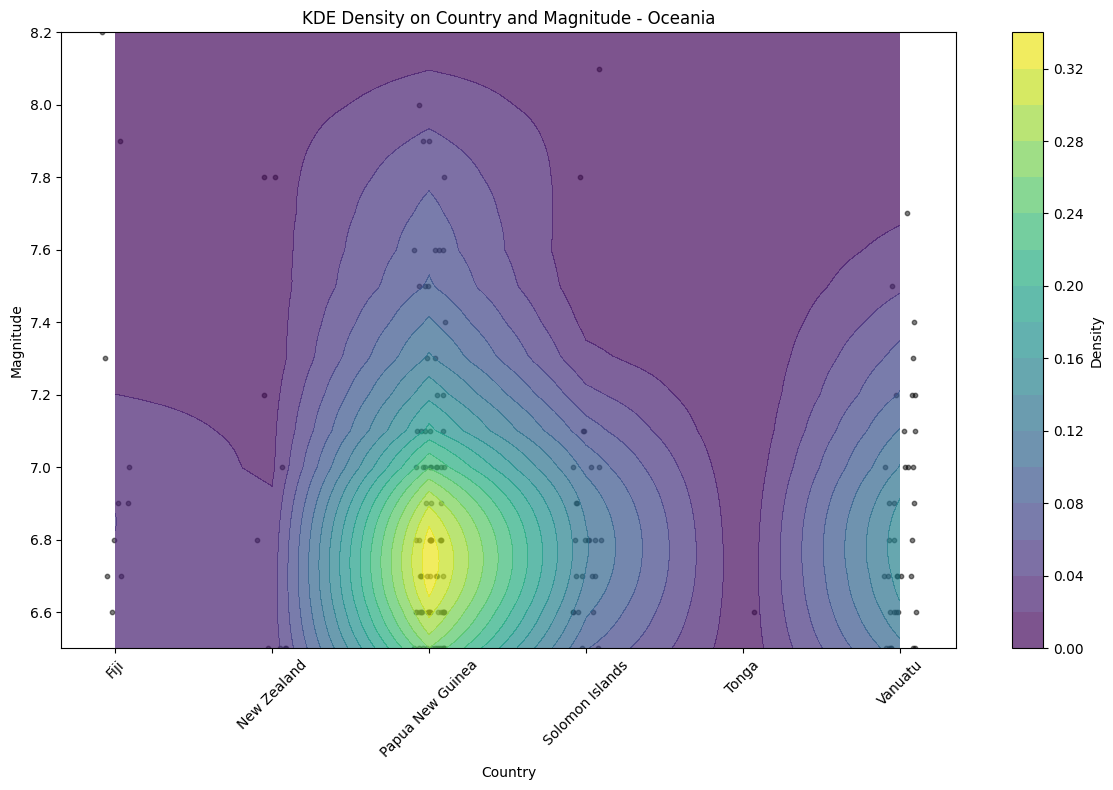

In [ ]:
# KDE Model
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KernelDensity

le = LabelEncoder()
df_filtered_Oceania['country_code'] = le.fit_transform(df_filtered_Oceania['earthquake_country'])

df_filtered_Oceania = df_filtered_Oceania.dropna(subset=['country_code', 'magnitude'])

features = df_filtered_Oceania[['country_code', 'magnitude']].values

kde = KernelDensity(bandwidth=0.5, kernel='cosine')
kde.fit(features)

unique_codes = np.sort(df_filtered_Oceania['country_code'].unique())
country_names = le.inverse_transform(unique_codes)

mag_min, mag_max = df_filtered_Oceania['magnitude'].min(), df_filtered_Oceania['magnitude'].max()
mag_grid = np.linspace(mag_min, mag_max, 100)

country_grid, mag_grid_mesh = np.meshgrid(unique_codes, mag_grid)
grid_points = np.vstack([country_grid.ravel(), mag_grid_mesh.ravel()]).T

log_density = kde.score_samples(grid_points)
density = np.exp(log_density).reshape(mag_grid_mesh.shape)

plt.figure(figsize=(12, 8))
plt.title('KDE Density on Country and Magnitude - Oceania')

plt.scatter(df_filtered_Oceania['country_code'] + np.random.uniform(-0.1,0.1,len(df_filtered_Oceania)),
            df_filtered_Oceania['magnitude'], s=10, c='k', alpha=0.5, label='Data points')
contour = plt.contourf(country_grid, mag_grid_mesh, density, levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(contour, label='Density')

plt.xticks(ticks=unique_codes, labels=country_names, rotation=45)
plt.xlabel('Country')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()
